### Visualizing and analysing Data using Neo 

#### hbp-d000017_PatchClamp-GranuleCells_pub
https://neo.readthedocs.io/en/latest/share_data.html

In [2]:
import os
import re
import glob
import zipfile
import numpy as np
from neo.io import get_io
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from neo import Epoch
import neo


In [3]:
sns.set_style()

### Data structure in NEO

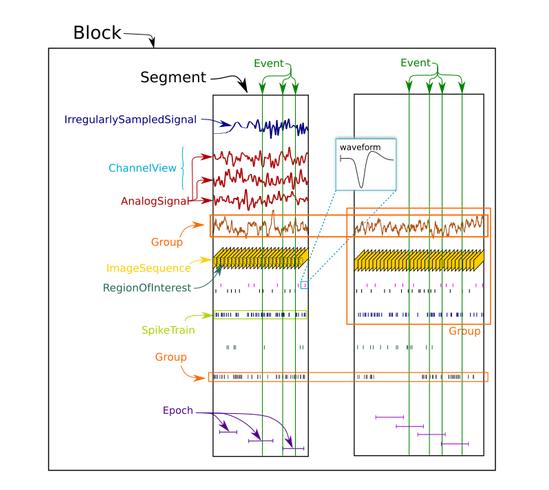

### Read data

from neo.io import AsciiSignalIO\
data_1 = AsciiSignalIO("exemple_data.txt", delimiter=" ".read()) # .txt\

from neo.io import get_io\
reader = get_io("path/to/the/data.abf")\
data_2 = reader.read()



### Functions

In [3]:
def find_path(working_directory, dataset_name): # Find the folder where the zip file is 
    """
    input: working directory: str: path #os.path.join(os.getcwd())
            dataset_name: str: name of the dataset EBRAINS same as the folder name
    output: path of the folder
    """
    dataset_name = dataset_name.replace(" ", "_")
    search_pattern = os.path.join(working_directory, f"{dataset_name}")
    dataset_directory = glob.glob(search_pattern)

    if dataset_directory:
        return dataset_directory[0] # type(files) -> list
    else:
        return f"No folder or file '{dataset_name}' in '{working_directory}'."
    
def find_zip_file(dataset_directory, dataset_name): # Find zip file in the folder
    zip_path = glob.glob(os.path.join(dataset_directory, '*.zip'))
    return zip_path[0]

def unzip_file(zip_path, dataset_directory): # Unzip and extract the zipfile in the chosen directory
    # Unzip folder (run one time) !!!
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(dataset_directory)

def plot_data(file_path):
    data = get_io(file_path).read(lazy=True)
    for segment in data[0].segments:
        signal = segment.analogsignals[0].load()
        plt.plot(signal.times, signal)
    #plt.xlim(0.0, 1) # MODIFIED REGULARLY
    #plt.ylim(-72,-60)
    plt.xlabel(f"Time ({signal.times.units.dimensionality})")
    plt.ylabel(f"Membrane potential (signal.units.dimensionality)")

def plot_data_zoom(file_path):
    data = get_io(file_path).read(lazy=True)
    for segment in data[0].segments:
        signal = segment.analogsignals[0].load()
        plt.plot(signal.times - signal.t_start, signal)
        plt.xlim(0.05, 0.5)
        plt.xlabel(f"Time ({signal.times.units.dimensionality})")
        plt.ylabel(f"Membrane potential ({signal.units.dimensionality})")


#Création d'une fonction qui permet d'avoir le début de la dépolarisation et la fin de l'hyperpolarisation
def onset(file_path):
    #Création de 3 liste vide
    var_signal0 = []
    var_signal1 = []
    var_signal = []
    data = get_io(file_path).read(lazy=True)
    for segment in data[0].segments:
        signal = segment.analogsignals[0].load()
        signalv = np.array(signal)
        #moyenne du repos
        mean = sum(signalv[:10])/len(signalv[:10])
        print('mean')
        #intervalle des valeurs considérer au repos
        interp = mean + 3
        interm = mean - 3
        #récupération des indices ou le signal change
        onset_test = signalv
        var_signal= [i for i, x in enumerate(signalv) if x > interp or x < interm]
        print(var_signal)
        #si il y a une valeur dans var_signal alors on rajoute la 1er valeur
        #dans var_signal0 = début de la variation du signal
        #la dernière valeur dans var_signal1 = fin de la variation du signal
        if len(var_signal) > 0:
            var_signal0.append(var_signal[0])
            var_signal1.append(var_signal[-1])
            #on récupère la plus petit valeur dans chaque signal
    var0 = min(var_signal0)
    var1 = min(var_signal1)
    return signal.times[var0]-signal.times[0], signal.times[var1]-signal.times[0]



In [4]:
# Variable - Whole cell patch-clamp_recordings_of_cerebellar_granule_cells 


working_directory = os.path.join(os.getcwd()).replace(" ", "_")
dataset_name = "Whole cell patch-clamp recordings of cerebellar granule cells"
dataset_version = "v1"

dataset_directory = find_path(working_directory, dataset_name)
#zip_path = find_zip_file(dataset_directory, dataset_name)
# unzip_file(zip_path,dataset_directory)
list_folders = os.listdir(path= '/home/abonard/Documents/EBRAINS/Curation/Examples/Whole_cell_patch-clamp_recordings_of_cerebellar_granule_cells') # get list of folders


dataset_directory = os.path.join(os.getcwd())
list_folders = os.listdir(path=dataset_directory) # get list of folders

In [5]:
working_directory = os.path.join(os.getcwd()).replace(" ", "_")
dataset_name = "Whole cell patch-clamp recordings of cerebellar granule cells"
dataset_version = "v1"
dataset_directory = find_path(working_directory, dataset_name)
dataset_directory = os.path.join(os.getcwd())
list_folders = os.listdir(path=dataset_directory) # get list of folders

### Organize data

In [6]:
df_path_subject_id = pd.DataFrame(columns=('subject_id', 'path_data', 'files')) # create the dataframe
df_path_subject_id['subject_id'] = [folder for folder in list_folders if folder.startswith('GrC') and os.path.isdir(os.path.join(dataset_directory, folder))] # get the id of each Subject
df_path_subject_id['path_data'] = df_path_subject_id['subject_id'].apply(lambda x: os.path.join(dataset_directory, x)) # get the path of the folder of each subject
df_path_subject_id['files'] = df_path_subject_id['path_data'].apply(os.listdir) # get in a list the data files 
df_path_subject_id.head()

,subject_id,path_data,files
0,GrC_Subject01_010818,/home/abonard/Documents/EBRAINS/Curation/Examp...,[010818_0002 CC step.abf]
1,GrC_Subject02_050918,/home/abonard/Documents/EBRAINS/Curation/Examp...,"[050918_0005 IV -70.abf, 050918_0006 CC step.abf]"
2,GrC_Subject03_060918,/home/abonard/Documents/EBRAINS/Curation/Examp...,[060918_0001 CC step.abf]
3,GrC_Subject04_070918,/home/abonard/Documents/EBRAINS/Curation/Examp...,"[070918_0000 IV -70.abf, 070918_0001 CC step.abf]"
4,GrC_Subject05_080316,/home/abonard/Documents/EBRAINS/Curation/Examp...,"[080316_0000 IV -70.abf, 080316_0001 CC step.abf]"


In [7]:
# keys = file name. ex.010818_0002 CC step.abf | values = neo.core.segment.Segment object at 0x7f2ad7b7e810 

dict_data = {}
for index, row in df_path_subject_id.iterrows():
    folder_path = row['path_data']
    file_names = row['files']
    
    # Loop through each file name in the 'name' list
    for file_name in file_names:
        file_path = f"{folder_path}/{file_name}"
        # Read the file into a DataFrame
        file_df = get_io(file_path)
        data_neo = file_df.read()
        dict_data[file_name] = data_neo

In [8]:
# Get Protocol CC step 

dict_data_CC = {}
for index, row in df_path_subject_id.iterrows():
    folder_path = row['path_data']
    file_names = row['files']

    for file in file_names:
        if 'CC step' in file:
            file_path = f"{folder_path}/{file}"
            file_df = get_io(file_path)
            data_neo = file_df.read()
            dict_data_CC[file] = data_neo

In [9]:
# Get Protocol IV - 70. 
dict_data_IV_70= {}

for index, row in df_path_subject_id.iterrows():
    folder_path = row['path_data']
    file_names = row['files']

    for file in file_names:
        if 'IV -70' in file:
            file_path = f"{folder_path}/{file}"
            file_df = get_io(file_path)
            data_neo = file_df.read()

            dict_data_IV_70[file] = data_neo


In [10]:
# Get Protocol EPSC. 
dict_data_EPSP = {}

for index, row in df_path_subject_id.iterrows():
    folder_path = row['path_data']
    file_names = row['files']

    for file in file_names:
        if 'EPSP' in file:
            file_path = f"{folder_path}/{file}"
            file_df = get_io(file_path)
            data_neo = file_df.read()
            dict_data_EPSP[file] = data_neo

#### Analysis Sampling frequency

In [12]:
# Get sampling rate For all protocols

print('-------')
print('signal_CC')
for file in dict_data_CC.keys():
    signal_CC = dict_data_CC[file][0].segments[0].analogsignals[0].sampling_rate
    print(signal_CC)

print('-------')
print('signal_IV_70')

for file in dict_data_IV_70.keys():
    signal_IV_70 = dict_data_IV_70[file][0].segments[0].analogsignals[0].sampling_rate
    print(signal_IV_70)

print('-------')
print('signal_EPSP')
for file in dict_data_EPSP.keys():
    signal_EPSP = dict_data_EPSP[file][0].segments[0].analogsignals[0].sampling_rate
    print(signal_EPSP)


-------
signal_CC
100000.0 Hz
100000.0 Hz
100000.0 Hz
100000.0 Hz
100000.0 Hz
100000.0 Hz
100000.0 Hz
100000.0 Hz
100000.0 Hz
100000.0 Hz
4000.0 Hz
100000.0 Hz
100000.0 Hz
4000.0 Hz
4000.0 Hz
100000.0 Hz
100000.0 Hz
100000.0 Hz
100000.0 Hz
100000.0 Hz
100000.0 Hz
100000.0 Hz
100000.0 Hz
4000.0 Hz
4000.0 Hz
4000.0 Hz
100000.0 Hz
100000.0 Hz
100000.0 Hz
-------
signal_IV_70
20000.0 Hz
20000.0 Hz
20000.0 Hz
20000.0 Hz
20000.0 Hz
50000.0 Hz
20000.0 Hz
50000.0 Hz
20000.0 Hz
20000.0 Hz
20000.0 Hz
50000.0 Hz
50000.0 Hz
20000.0 Hz
50000.0 Hz
50000.0 Hz
20000.0 Hz
20000.0 Hz
20000.0 Hz
20000.0 Hz
-------
signal_EPSP
100000.0 Hz
100000.0 Hz
100000.0 Hz
100000.0 Hz
100000.0 Hz
100000.0 Hz
100000.0 Hz
100000.0 Hz
100000.0 Hz
100000.0 Hz
100000.0 Hz
100000.0 Hz
100000.0 Hz
100000.0 Hz
100000.0 Hz


### Analysis - Simulation 

### Issue space

In [42]:
reader = get_io('GrC_Subject15_180116/180116_0004 IV -70.abf')


In [43]:
reader

AxonIO: GrC_Subject15_180116/180116_0004 IV -70.abf
nb_block: 1
nb_segment:  [8]
signal_streams: [Signals (chans: 2)]
signal_channels: [IN0, leak1]
spike_channels: []
event_channels: [Tag]

In [44]:
data = reader.read()

In [45]:
data

[Block with [<neo.core.segment.Segment object at 0x7fb0a158eea0>, <neo.core.segment.Segment object at 0x7fb0a126e510>, <neo.core.segment.Segment object at 0x7fb09ce19f40>, <neo.core.segment.Segment object at 0x7fb09ce1af30>, <neo.core.segment.Segment object at 0x7fb09ce1ad50>, <neo.core.segment.Segment object at 0x7fb0a17c8cb0>, <neo.core.segment.Segment object at 0x7fb0a1075af0>, <neo.core.segment.Segment object at 0x7fb0a0bc9e50>] segments, [<neo.core.group.Group object at 0x7fb09fcde7b0>] groups
 annotations: {'abf_version': 2.0}
 file_origin: 'GrC_Subject15_180116/180116_0004 IV -70.abf'
 rec_datetime: datetime.datetime(2016, 1, 18, 16, 24, 54, 781000)
 # segments (N=[<neo.core.segment.Segment object at 0x7fb0a158eea0>, <neo.core.segment.Segment object at 0x7fb0a126e510>, <neo.core.segment.Segment object at 0x7fb09ce19f40>, <neo.core.segment.Segment object at 0x7fb09ce1af30>, <neo.core.segment.Segment object at 0x7fb09ce1ad50>, <neo.core.segment.Segment object at 0x7fb0a17c8cb0>, <

#### Simulation Onset

In [23]:
data = get_io('GrC_Subject15_180116/180116_0004 IV -70.abf').read(lazy=True)
for segment in data[0].segments:
    signal = segment.analogsignals[0].load()
    signalv = np.array(signal)
signalv[0]

array([-7.93457  , -1.0986328], dtype=float32)

In [31]:
np.array(data[0].segments[0].analogsignals[0].load())

array([[-3.6621091 , -0.61035156],
       [-4.8828125 , -0.79345703],
       [-6.7138667 , -0.9765625 ],
       ...,
       [-7.3242183 , -1.0375977 ],
       [-7.3242183 , -1.0375977 ],
       [-9.765625  , -1.2207031 ]], dtype=float32)

In [22]:
df = pd.DataFrame([signalv[0]], columns=['Colonne1', 'Colonne2'])


,Colonne1,Colonne2
0,-7.93457,-1.098633


In [17]:
len(data[1:])

40000

In [20]:
for row in signalv:
    data.append(row)
df = pd.DataFrame(data[1:], columns=['Colonne1', 'Colonne2']) #data[0] -> <neo.core.block.Block object at 0x7fb0a13b7740>

In [22]:
segment.analogsignals[0]

AnalogSignal with 2 channels of length 20000; units pA; datatype float32
name: 'Signals'
annotations: {'stream_id': '0'}
sampling rate: 20000.0 Hz
time: 56.0 s to 57.0 s

In [31]:
for row in signalv:
    data.append(row)

print(type(data[2]))

<class 'numpy.ndarray'>


In [ ]:
for index, row in df_path_subject_id.iterrows():
    folder_path = row['path_data']
    file_names = row['files']

    for file in file_names:
        if 'CC step' in file:
            file_path = f"{folder_path}/{file}"
            debut = onset(file_path)
            print(debut)


(array(0.10033) * s, array(2.10677) * s)
(array(0.09007) * s, array(2.06274) * s)
(array(0.10007) * s, array(2.10553) * s)
(array(0.10063) * s, array(2.10578) * s)
(array(0.10006) * s, array(2.11261) * s)
(array(0.02971) * s, array(2.76441) * s)
(array(0.10041) * s, array(2.11128) * s)
(array(0.10059) * s, array(2.10264) * s)
(array(0.10007) * s, array(1.63595) * s)
(array(0.10036) * s, array(2.10339) * s)
(array(0.09425) * s, array(2.10175) * s)
(array(0.1004) * s, array(2.10589) * s)
(array(0.10057) * s, array(1.99141) * s)
(array(0.1005) * s, array(2.088) * s)
(array(0.10025) * s, array(1.4405) * s)
(array(0.10063) * s, array(2.10867) * s)
(array(0.10029) * s, array(2.10281) * s)
(array(0.10054) * s, array(2.10163) * s)
(array(0.0247) * s, array(2.09979) * s)
(array(0.10024) * s, array(2.10363) * s)
(array(0.03098) * s, array(2.11209) * s)
(array(0.04457) * s, array(2.11387) * s)
(array(0.10052) * s, array(2.13023) * s)
(array(0.02375) * s, array(2.33575) * s)
(array(0.1005) * s, ar

In [66]:
for index, row in df_path_subject_id.iterrows():
    folder_path = row['path_data']
    file_names = row['files']

    for file in file_names:
        if 'CC step' in file:
            file_path = f"{folder_path}/{file}"
            debut = onset(file_path)
            print(debut)

(array(0.10033) * s, array(2.10677) * s)
(array(0.09007) * s, array(2.06274) * s)
(array(0.10007) * s, array(2.10553) * s)
(array(0.10063) * s, array(2.10578) * s)
(array(0.10006) * s, array(2.11261) * s)
(array(0.02971) * s, array(2.76441) * s)
(array(0.10041) * s, array(2.11128) * s)
(array(0.10059) * s, array(2.10264) * s)
(array(0.10007) * s, array(1.63595) * s)
(array(0.10036) * s, array(2.10339) * s)
(array(0.09425) * s, array(2.10175) * s)
(array(0.1004) * s, array(2.10589) * s)
(array(0.10057) * s, array(1.99141) * s)
(array(0.1005) * s, array(2.088) * s)
(array(0.10025) * s, array(1.4405) * s)
(array(0.10063) * s, array(2.10867) * s)
(array(0.10029) * s, array(2.10281) * s)
(array(0.10054) * s, array(2.10163) * s)
(array(0.0247) * s, array(2.09979) * s)
(array(0.10024) * s, array(2.10363) * s)
(array(0.03098) * s, array(2.11209) * s)
(array(0.04457) * s, array(2.11387) * s)
(array(0.10052) * s, array(2.13023) * s)
(array(0.02375) * s, array(2.33575) * s)
(array(0.1005) * s, ar

In [39]:
for index, row in df_path_subject_id.iterrows():
    folder_path = row['path_data']
    file_names = row['files']
    for file in file_names:
        if 'IV -70' in file:
            file_path = f"{folder_path}/{file}"
            #debut = onset(file_path)
            print(file_path)

/home/abonard/Documents/EBRAINS/Curation/Examples/Whole_cell_patch-clamp_recordings_of_cerebellar_granule_cells/GrC_Subject02_050918/050918_0005 IV -70.abf
/home/abonard/Documents/EBRAINS/Curation/Examples/Whole_cell_patch-clamp_recordings_of_cerebellar_granule_cells/GrC_Subject04_070918/070918_0000 IV -70.abf
/home/abonard/Documents/EBRAINS/Curation/Examples/Whole_cell_patch-clamp_recordings_of_cerebellar_granule_cells/GrC_Subject05_080316/080316_0000 IV -70.abf
/home/abonard/Documents/EBRAINS/Curation/Examples/Whole_cell_patch-clamp_recordings_of_cerebellar_granule_cells/GrC_Subject06_090216/090216_0002  IV -70.abf
/home/abonard/Documents/EBRAINS/Curation/Examples/Whole_cell_patch-clamp_recordings_of_cerebellar_granule_cells/GrC_Subject07_100918/100918_0000 IV -70.abf
/home/abonard/Documents/EBRAINS/Curation/Examples/Whole_cell_patch-clamp_recordings_of_cerebellar_granule_cells/GrC_Subject08_101018/101018-B_0006 IV -70.abf
/home/abonard/Documents/EBRAINS/Curation/Examples/Whole_cell_

In [16]:
#Création de 3 liste vide
var_signal0 = []
var_signal1 = []
var_signal = []
data = get_io('/home/abonard/Documents/EBRAINS/Curation/Examples/Whole_cell_patch-clamp_recordings_of_cerebellar_granule_cells/GrC_Subject02_050918/050918_0005 IV -70.abf').read(lazy=True)
for segment in data[0].segments:
    signal = segment.analogsignals[0].load()
    signalv = np.array(signal)
    print(signalv)
    #moyenne du repos
    mean = sum(signalv[:10])/len(signalv[:10])
    print('mean')
    #intervalle des valeurs considérer au repos
    interp = mean + 3
    interm = mean - 3
    #récupération des indices ou le signal change
    var_signal= [i for i, x in enumerate(signalv) if x > interp or x < interm]
    print('var_signal')
    #si il y a une valeur dans var_signal alors on rajoute la 1er valeur
    #dans var_signal0 = début de la variation du signal
    #la dernière valeur dans var_signal1 = fin de la variation du signal
    if len(var_signal) > 0:
        var_signal0.append(var_signal[0])
        var_signal1.append(var_signal[-1])
        #on récupère la plus petit valeur dans chaque signal
var0 = min(var_signal0)
var1 = min(var_signal1)
return_= signal.times[var0]-signal.times[0], signal.times[var1]-signal.times[0]


[[-7.93457    -1.0986328 ]
 [-4.272461   -0.6713867 ]
 [-9.765625   -1.2207031 ]
 ...
 [-9.155273   -1.159668  ]
 [-8.544922   -1.0986328 ]
 [-1.8310546  -0.48828125]]
mean


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [23]:
signalv

array([[-7.93457   , -1.0986328 ],
       [-4.272461  , -0.6713867 ],
       [-9.765625  , -1.2207031 ],
       ...,
       [-9.155273  , -1.159668  ],
       [-8.544922  , -1.0986328 ],
       [-1.8310546 , -0.48828125]], dtype=float32)

In [22]:
for i, x in enumerate(signalv):
     if x == interp :
        var_signal= 'yes'

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [ ]:
for index, row in df_path_subject_id.iterrows():
    folder_path = row['path_data']
    file_names = row['files']

    for file in file_names:
        if 'EPSP' in file:
            file_path = f"{folder_path}/{file}"
            debut = onset(file_path)
            print(debut)

In [ ]:
def plot_data_zoom(file_path):
    data = get_io(file_path).read(lazy=True)
    for segment in data[0].segments:
        signal = segment.analogsignals[0].load()
        plt.plot(signal.times - signal.t_start, signal)
    plt.xlim(0.05, 0.55)
    plt.xlabel(f"Time ({signal.times.units.dimensionality})")
    plt.ylabel(f"Membrane potential ({signal.units.dimensionality})")
    

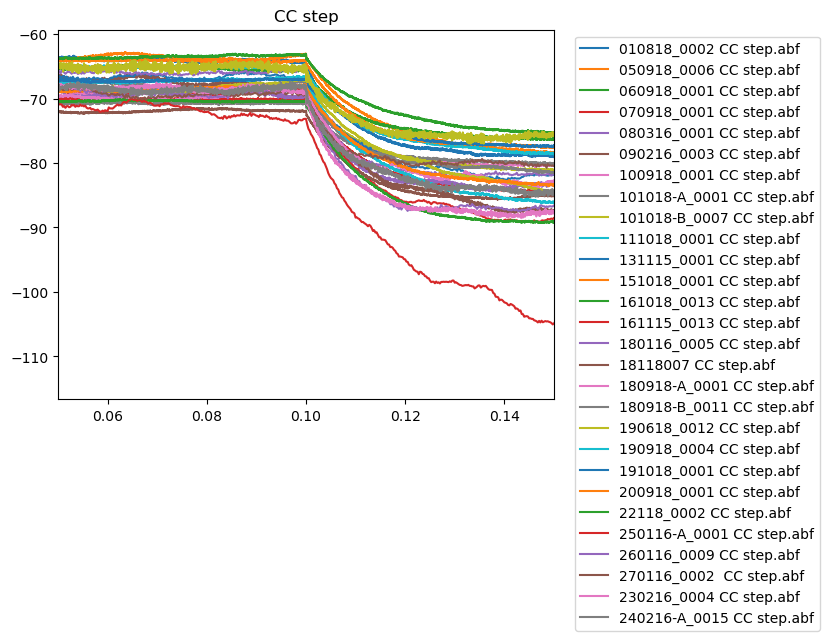

In [39]:
for file in dict_data_CC.keys():
    signal = dict_data_CC[file][0].segments[0].analogsignals[0]

    plt.title('CC step')
    plt.xlim(0.05,0.15)

    plt.legend(dict_data_CC.keys(),bbox_to_anchor=(1.55, 1.0),loc='upper right')
    plt.plot(signal.times, signal) 


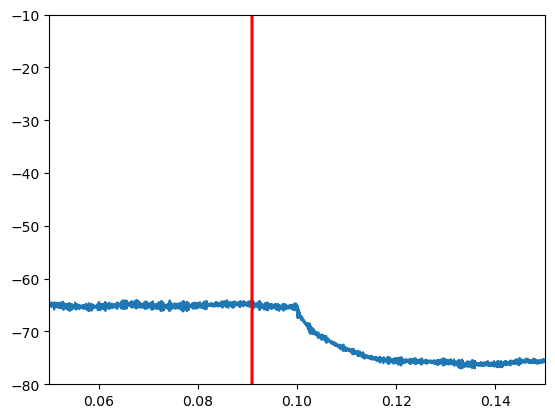

In [191]:
#for file in dict_data_CC.keys():
for segment in dict_data_CC['240216-B_0004 CC step.abf'][0].segments:
    signal = segment.analogsignals[0]
    signalv = np.array(signal)
    plt.plot(signal.times, signalv)
    #plt.xlim(60.09,60.135)
    plt.xlim(0.05,0.15)
    plt.ylim(-80, -10)
    plt.axvline(x=0.09085, color='r')

(60.09, 60.135)

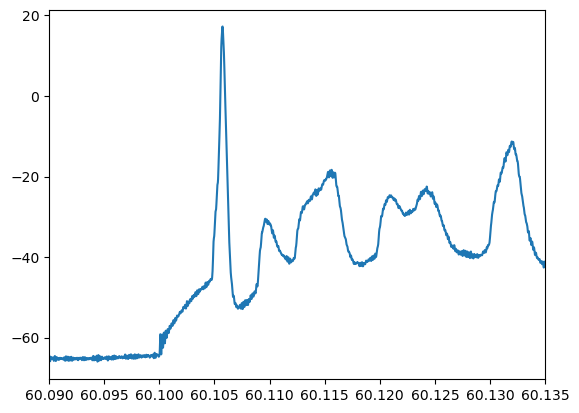

In [ ]:
for segment in data[0].segments:
    signal = segment.analogsignals[0].load()
    signalv = np.array(signal)
plt.plot(signal.times, signalv)
plt.xlim(60.09,60.135)

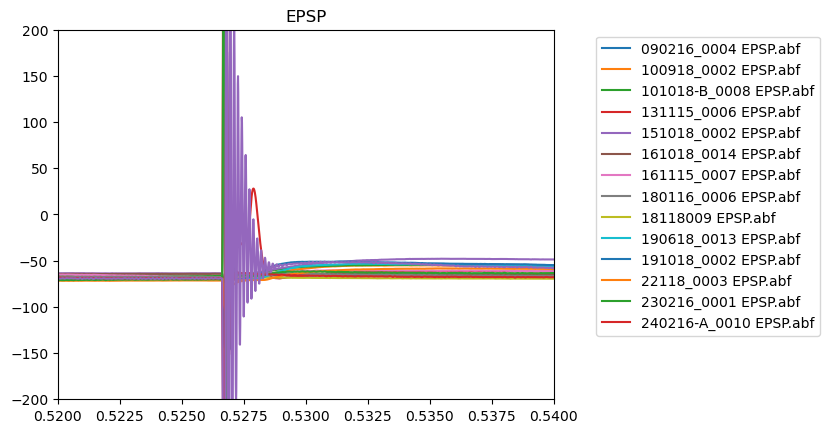

In [46]:
# EPSP

for file in dict_data_EPSP.keys():
    signal = dict_data_EPSP[file][0].segments[0].analogsignals[0]

    plt.title('EPSP')
    plt.xlim(0.52,0.54)
    plt.ylim(-200,200)

    plt.legend(dict_data_EPSP.keys(),bbox_to_anchor=(1.55, 1.0),loc='upper right')
    plt.plot(signal.times, signal) 


In [49]:
file

'240216-B_0001 EPSP.abf'

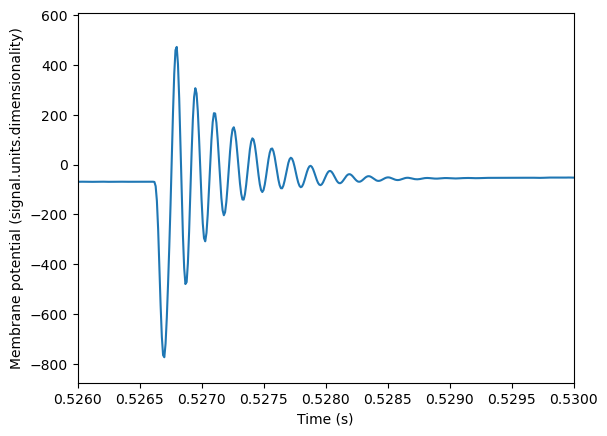

In [76]:
plot_data('GrC_Subject28_240216/240216-B_0001 EPSP.abf') # plot data function modified - plt.plot(0.526, 0.53)

#### Simulation Amplitude

Le nombre de segment est indicateur du nombre d'amplitudes 

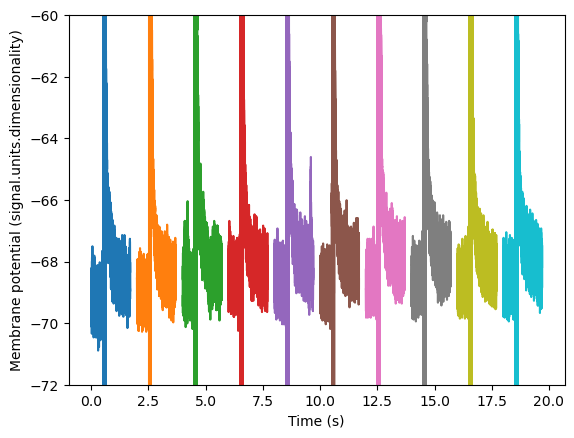

In [94]:
plot_data('GrC_Subject28_240216/240216-B_0001 EPSP.abf') # plot data function modified - plt.plot(0.526, 0.53)

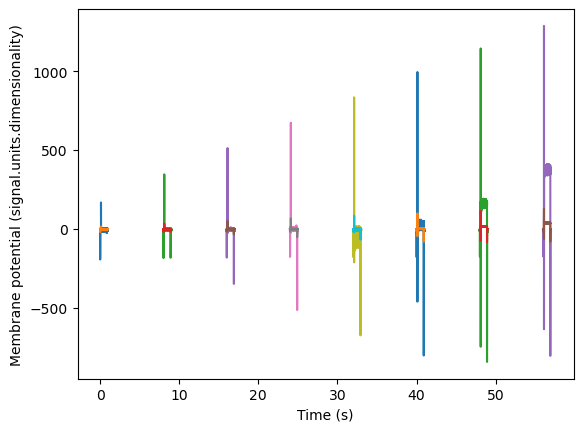

In [27]:
plot_data('GrC_Subject15_180116/180116_0004 IV -70.abf') # plot data function modified - plt.plot(0.526, 0.53)

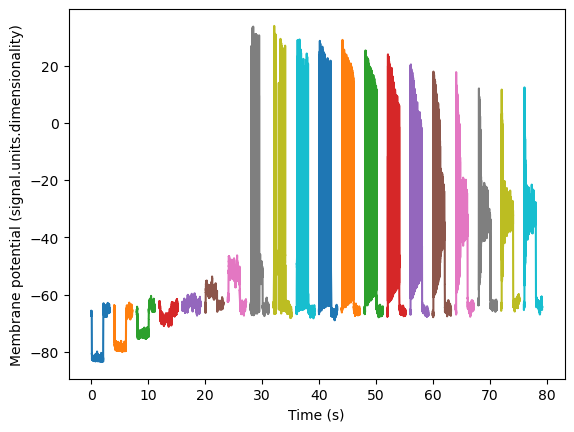

In [11]:
plot_data('GrC_Subject11_131115/131115_0001 CC step.abf') # plot data function modified - plt.plot(0.526, 0.53)

#### Simulation Duration 

#### Simulation interval

## Visualisation data

#### Visualisation 1 file 

In [197]:
file_path

'/home/abonard/Documents/EBRAINS/Curation/Examples/Whole_cell_patch-clamp_recordings_of_cerebellar_granule_cells/GrC_Subject28_240216/240216-B_0004 CC step.abf'

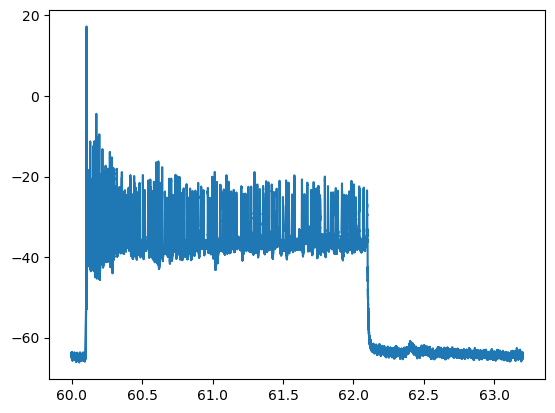

In [196]:
data = get_io(file_path).read(lazy=True)
for segment in data[0].segments:
    signal = segment.analogsignals[0].load()
    signalv = np.array(signal)
plt.plot(signal.times, signalv)
#plt.xlim(60.09,60.135)

#### Visualisation protocols files 

In [ ]:
# Plot_all_the_file - Script example
# Do ot run - 9- 10 mins
# To do: block.filter()

for index, row in df_path_subject_id.iterrows():
    file_names = row['files']
    
    # Loop through each file name in the 'name' list
    for file_name in file_names:
        for keys in dict_data[file_name]:   
            for segment in dict_data[file_name][0].segments:
                signal = segment.analogsignals[0]
                plt.title(file_name)
                plt.legend(row) # fix the axis indiquer le subject
                plt.plot(signal.times, signal) 
                


KeyboardInterrupt: 

/home/abonard/anaconda3/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/home/abonard/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


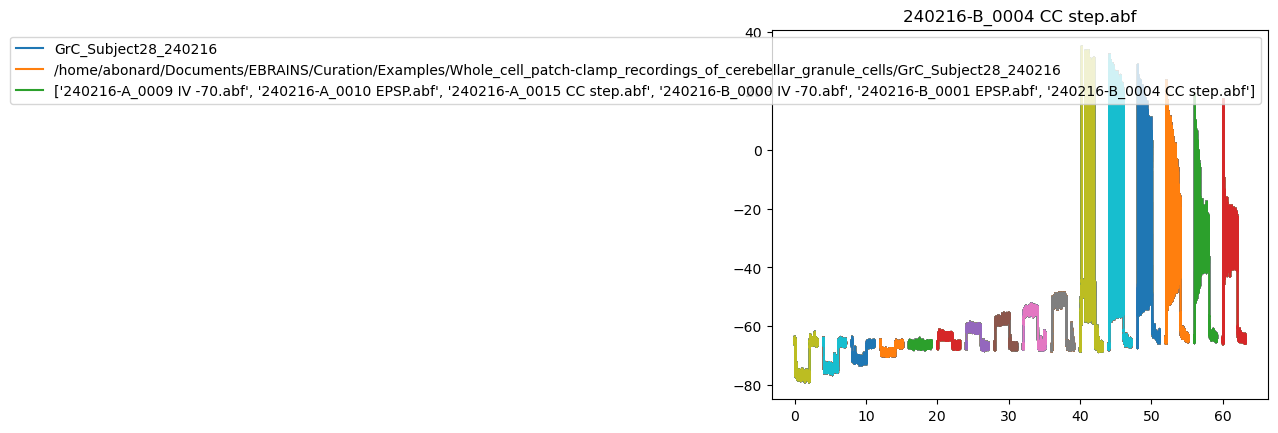

In [72]:
# Visualize CC step

for index, row in df_path_subject_id.iterrows():
    file_names = row['files']
    
    # Loop through each file name in the 'name' list
    for file_name in file_names:
        for keys in dict_data_CC[file]:   
            for segment in dict_data_CC[file][0].segments:
                print()
                signal = segment.analogsignals[0]
                plt.title(file)
                plt.plot(signal.times, signal) 


In [13]:
dict_data_CC = {}
for index, row in df_path_subject_id.iterrows():
    folder_path = row['path_data']
    file_names = row['files']

    for element in file_names:
        if 'CC step' in element:
            file_path = f"{folder_path}/{element}"
            file_df = get_io(file_path)
            data_neo = file_df.read()
            dict_data_CC[element] = data_neo


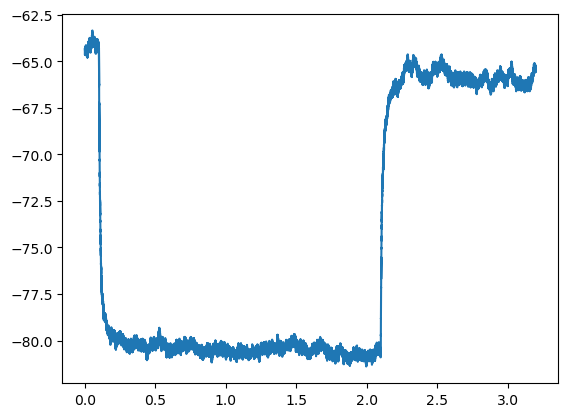

In [14]:
dict_data_CC['010818_0002 CC step.abf'][0].segments[0].analogsignals[0]
plt.plot(dict_data_CC['010818_0002 CC step.abf'][0].segments[0].analogsignals[0].times, dict_data_CC['010818_0002 CC step.abf'][0].segments[0].analogsignals[0]) 


In [ ]:

            for file_name in file_names:
        for keys in dict_data[file_name]:   
            for segment in dict_data[file_name][0].segments:
                signal = segment.analogsignals[0]
                plt.title(file_name)
                plt.legend(row) # fix the axis indiquer le subject
                plt.plot(signal.times, signal) 
                plt.show()


In [15]:
for keys in dict_data_CC:
    print(keys)   
    for segment in dict_data_CC[file_name][0].segments:
        signal = segment.analogsignals[0]
        plt.title(file_name)
        plt.legend(row) # fix the axis indiquer le subject
        plt.plot(signal.times, signal) 


010818_0002 CC step.abf
050918_0006 CC step.abf
060918_0001 CC step.abf
070918_0001 CC step.abf
080316_0001 CC step.abf
090216_0003 CC step.abf
100918_0001 CC step.abf
101018-A_0001 CC step.abf
101018-B_0007 CC step.abf
111018_0001 CC step.abf
131115_0001 CC step.abf
151018_0001 CC step.abf
161018_0013 CC step.abf
161115_0013 CC step.abf
180116_0005 CC step.abf
18118007 CC step.abf
180918-A_0001 CC step.abf
180918-B_0011 CC step.abf
190618_0012 CC step.abf
190918_0004 CC step.abf
191018_0001 CC step.abf
200918_0001 CC step.abf
22118_0002 CC step.abf
250116-A_0001 CC step.abf
260116_0009 CC step.abf
270116_0002  CC step.abf
230216_0004 CC step.abf
240216-A_0015 CC step.abf
240216-B_0004 CC step.abf
Error in callback <function flush_figures at 0x7f5c3c5eae80> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

### Hands on Neo

block is a recording session\
block contains segment\
segments contain data recorded at the same time

In [71]:
#Data_type: AnalogSignal
print("data units",data[0].segments[0].analogsignals[0].units) 
#print(data[0].segments[0].analogsignals[0].rescale("V").units) # change units
print("times",data[0].segments[0].analogsignals[0].times)
print("time units",data[0].segments[0].analogsignals[0].times.units)#
print("dimensiopnality_time",data[0].segments[0].analogsignals[0].times.units.dimensionality)
print("dimensiopnality_signal",data[0].segments[0].analogsignals[0].units.dimensionality)
print("sampling rate",data[0].segments[0].analogsignals[0].sampling_rate)
print("signal_name",data[0].segments[0].analogsignals[0].name)
# optional 
print("array_annotations",data[0].segments[0].analogsignals[0].array_annotations)# units
print("means",data[0].segments[0].analogsignals[0].mean())
print("magnitude",data[0].segments[0].analogsignals[0].magnitude)#convert a Neo data object to a plain NumPy array
print("slincing_array_",data[0].segments[0].analogsignals[1:2])
print("signal_name",data[0].segments[0].analogsignals[0].name)


data units 1.0 mV
times [0.00000e+00 1.00000e-05 2.00000e-05 ... 3.19997e+00 3.19998e+00
 3.19999e+00] s
time units 1.0 s
dimensiopnality_time s
dimensiopnality_signal mV
sampling rate 100000.0 Hz
signal_name Channels: (IN0)
array_annotations {'channel_names': array(['IN0'], dtype='<U5'), 'channel_ids': array(['0'], dtype='<U1'), 'nADCNum': array([0])}
means -74.93118 mV
magnitude [[-64.36157 ]
 [-64.30054 ]
 [-64.30054 ]
 ...
 [-65.338135]
 [-65.39917 ]
 [-65.55176 ]]
slincing_array_ [<AnalogSignal(array([[-129.02832],
       [-128.90625],
       [-128.90625],
       ...,
       [-130.98145],
       [-131.16455],
       [-131.28662]], dtype=float32) * pA, [0.0 s, 3.2 s], sampling rate: 100000.0 Hz)>]
signal_name Channels: (IN0)


In [81]:
data[0].segments[0].irregularlysampledsignals

[]

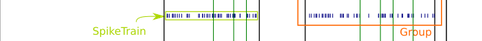

In [80]:
data[0].segments[0].spiketrains

<SpikeTrainList>

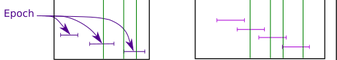

In [74]:
data[0].segments[0].epochs

[]

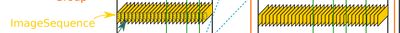

In [75]:
data[0].segments[0].imagesequences

[]

### Annotation - Simulation - Github

In [ ]:
adapting = "hbp-d000017_PatchClamp-GranuleCells_pub/GrC_Subject15_180116/180116_0005 CC step.abf"
non_adapting="hbp-d000017_PatchClamp-GranuleCells_pub/GrC_Subject06_090216/090216_0003 CC step.abf"
accelerating="hbp-d000017_PatchClamp-GranuleCells_pub/GrC_Subject10_111018/111018_0001 CC step.abf"

In [ ]:
listTime=[]
listVolt=[]
listFile=[adapting,non_adapting,accelerating]

for file_path in listFile:
    data = {}
    data[file_path] = get_io(file_path).read(lazy=True)[0]
    ch = data[file_path].segments[9].filter(channel_id=0)[0].load() #index_10pA = 9
    time= ch.times.magnitude*1000 #convert to ms
    time=list(time-time[0])
    volt=list(ch.magnitude.flatten())

    listTime.append(time)
    listVolt.append(volt)

In [11]:
for file_name in file_names:
        file_path = f"{folder_path}/{file_name}"
        # Read the file into a DataFrame
        file_df = get_io(file_path)
        data_neo = file_df.read()
        dict_data[file_name] = data_neo

# Plot_all_the_file

for index, row in df_path_subject_id.iterrows():
    file_names = row['files']
    
    # Loop through each file name in the 'name' list
    for file_name in file_names:
        for keys in dict_data[file_name]:   
            for segment in dict_data[file_name][0].segments:
                signal = segment.analogsignals[0]
                #plt.title(file_name)
               # plt.legend(row) # fix the axis indiquer le subject
                #plt.plot(signal.times, signal) 
               # plt.show()


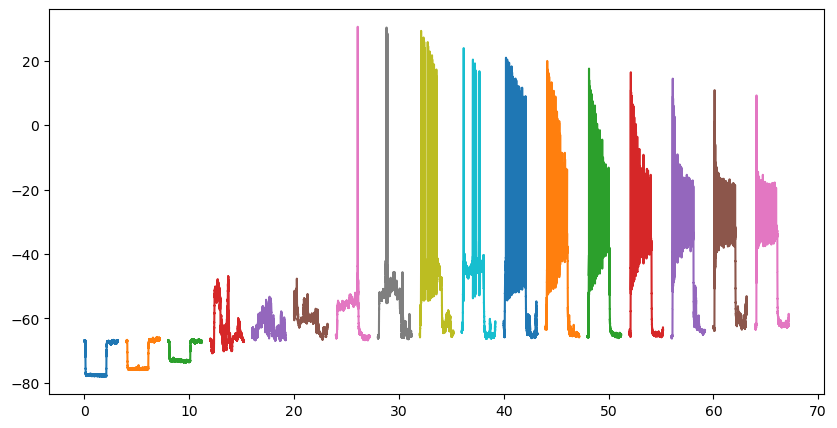

In [142]:
fig = plt.figure(figsize=(10, 5))
for segment in data[0].segments:
    signal = segment.analogsignals[0]
    plt.plot(signal.times, signal)
